# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030


# Exercise 1 — SVM on a Quadratic Decision Boundary

**Goal:** Generate a random 2D dataset whose two classes are separated by a **quadratic**
(parabolic) boundary rather than a straight line, then use a **Support Vector Machine** to learn
that boundary. This is the classic illustration of why kernel choice matters: a linear SVM cannot
separate the classes well, while an SVM with a **polynomial** (or RBF) kernel can, because the
kernel implicitly maps the data into a higher-dimensional space where a linear separator
corresponds to a curved boundary in the original 2D space.

We'll:
1. Generate random points and label them by which side of a parabola (`y = x² + noise`) they fall on
2. Fit a **linear-kernel SVM** and see it struggle
3. Fit **polynomial-kernel** and **RBF-kernel** SVMs and see them correctly learn the quadratic boundary
4. Visualize all three decision boundaries side by side


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NAME: MADDIPATLA CHETAN
# ROLL NO:CH.SC.U4CSE24030

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Generate a random dataset with a quadratic decision boundary

Points `(x, y)` are drawn uniformly at random; a point is labeled **Class 1** if it falls **above**
the parabola `y = 0.5·x² - 1` (plus a little label noise for realism) and **Class 0** otherwise.


In [2]:
def generate_quadratic_data(n=500, seed=42, noise=0.05):
    rng = np.random.default_rng(seed)

    x = rng.uniform(-3, 3, n)
    y = rng.uniform(-3, 6, n)

    boundary = 0.5 * x**2 - 1
    label = (y > boundary).astype(int)

    # Flip a small fraction of labels to add realistic noise
    flip_mask = rng.random(n) < noise
    label[flip_mask] = 1 - label[flip_mask]

    return pd.DataFrame({"x": x, "y": y, "label": label})


df = generate_quadratic_data(500, seed=RANDOM_STATE)
print("Rows:", len(df))
print(df["label"].value_counts())
df.head()


Rows: 500
label
1    308
0    192
Name: count, dtype: int64


,x,y,label
0,1.643736,3.630351,1
1,-0.366729,4.977626,1
2,2.151588,5.289515,1
3,1.184208,1.532696,1
4,-2.434936,1.682476,0


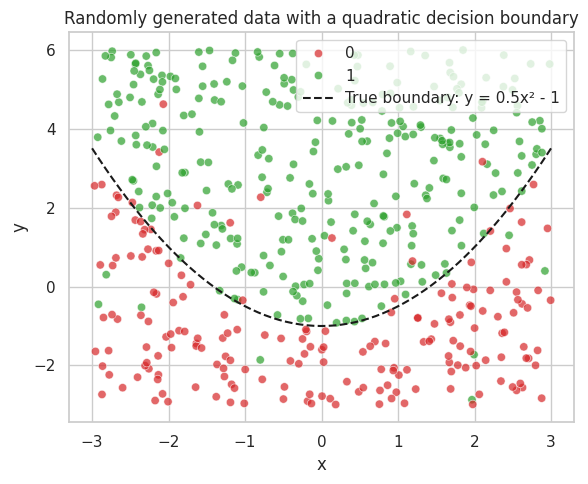

In [3]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="x", y="y", hue="label", palette=["#d62728", "#2ca02c"], alpha=0.7)
x_line = np.linspace(-3, 3, 200)
plt.plot(x_line, 0.5 * x_line**2 - 1, "k--", label="True boundary: y = 0.5x² - 1")
plt.title("Randomly generated data with a quadratic decision boundary")
plt.legend()
plt.tight_layout()
plt.show()


## 2. Train / test split and scaling

In [4]:
X = df[["x", "y"]].values
y_target = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.25, random_state=RANDOM_STATE, stratify=y_target
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


## 3. Fit SVMs with different kernels

- **Linear kernel** — can only draw a straight-line boundary; expect it to underperform here.
- **Polynomial kernel (degree 2)** — matches the true quadratic boundary almost exactly.
- **RBF kernel** — a flexible, general-purpose non-linear kernel that should also capture the curve well.


In [5]:
models = {
    "Linear kernel":        SVC(kernel="linear", C=1.0, random_state=RANDOM_STATE),
    "Polynomial kernel (deg=2)": SVC(kernel="poly", degree=2, C=1.0, coef0=1, random_state=RANDOM_STATE),
    "RBF kernel":            SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name:28s} test accuracy: {acc:.3f}")


Linear kernel                test accuracy: 0.824
Polynomial kernel (deg=2)    test accuracy: 0.912
RBF kernel                   test accuracy: 0.904


## 4. Visualize the decision boundary each kernel learns

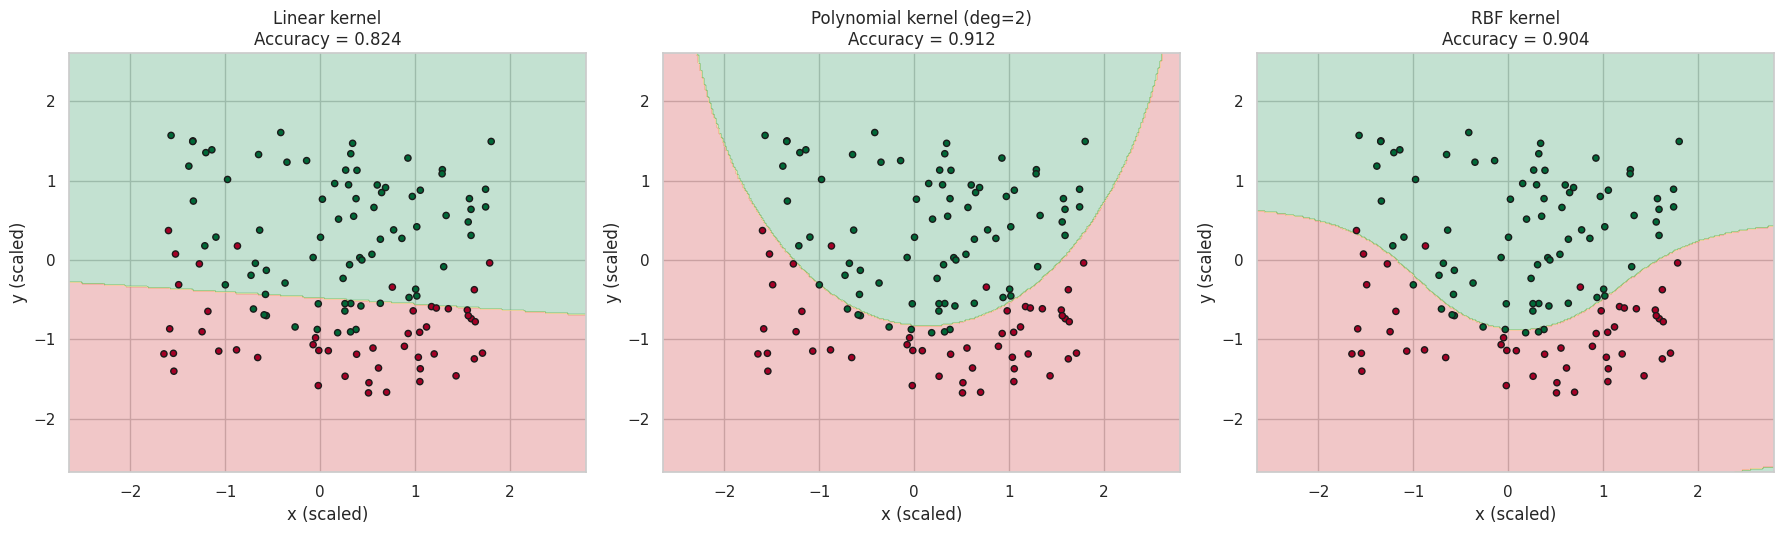

In [6]:
def plot_decision_boundary(ax, model, X_s, y_true, title):
    x_min, x_max = X_s[:, 0].min() - 1, X_s[:, 0].max() + 1
    y_min, y_max = X_s[:, 1].min() - 1, X_s[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="RdYlGn")
    ax.scatter(X_s[:, 0], X_s[:, 1], c=y_true, cmap="RdYlGn", edgecolor="k", s=20)
    ax.set_title(title)
    ax.set_xlabel("x (scaled)")
    ax.set_ylabel("y (scaled)")


fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (name, model) in zip(axes, models.items()):
    plot_decision_boundary(ax, model, X_test_s, y_test, f"{name}\nAccuracy = {results[name]:.3f}")

plt.tight_layout()
plt.show()


**Observation:** the linear-kernel SVM draws a straight line and misclassifies a whole region
of points near the curve. The polynomial (degree 2) and RBF kernels both bend their decision
boundary to follow the true parabola, giving noticeably higher accuracy — this is the practical
payoff of the "kernel trick": SVMs can learn non-linear boundaries by implicitly operating in a
higher-dimensional feature space, without ever explicitly computing that transformation.


## 5. Closer look at the best model

Best kernel: Polynomial kernel (deg=2)  (accuracy = 0.912)

              precision    recall  f1-score   support

     Class 0       0.84      0.96      0.89        48
     Class 1       0.97      0.88      0.93        77

    accuracy                           0.91       125
   macro avg       0.90      0.92      0.91       125
weighted avg       0.92      0.91      0.91       125



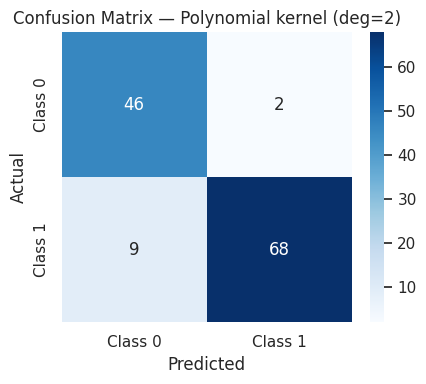

In [7]:
best_name = max(results, key=results.get)
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_s)

print(f"Best kernel: {best_name}  (accuracy = {results[best_name]:.3f})")
print()
print(classification_report(y_test, y_pred_best, target_names=["Class 0", "Class 1"]))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()
